In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Building and Analysing an Ensemble Classifier for Heart Disease Prediction

### Context & Goal

You are a data scientist for a healthcare research institute investigating predictive systems for cardiovascular risk assessment. Your objective is to build and critically evaluate an **ensemble of classifiers** that collectively determine whether a patient is likely to develop heart disease.

You will:

1. Design and justify the inclusion of heterogeneous base models.
2. Evaluate each base model’s standalone accuracy.
3. Combine them through **majority voting**.
4. Analyse bias, variance, and complementarity among the models.

### Dataset

**Name:** Heart Disease Dataset (Cleveland subset)
**Source:** [UCI Heart Disease Repository](https://archive.ics.uci.edu/ml/datasets/heart+Disease)

**Features (selected examples):**

* `age`, `sex`, `cp` (chest pain type) <br>
* `trestbps` (resting blood pressure) <br>
* `chol` (serum cholesterol) <br>
* `thalach` (maximum heart rate achieved) <br>
* `oldpeak` (ST depression induced by exercise) <br>
* `ca`, `thal` (angiographic data) <br>

**Target:**
`target` (binary — 1 indicates presence of heart disease, 0 otherwise).


### Phase 1 – Preprocessing & Design Decisions

1. Load the dataset from an online repository or local file.
2. Handle missing data (e.g. impute with median or drop rows).
3. Normalise or standardise numeric features (especially for KNN and Logistic Regression).
4. Split the data into **training (70%)** and **testing (30%)** sets with a fixed random state.
5. Clearly justify your preprocessing strategy — different classifiers have different assumptions (e.g. KNN is sensitive to scaling).

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

In [5]:
# Check the original target distribution
print("Original target distribution:")
print(y.value_counts().sort_index())
print(f"\nUnique values: {sorted(y['num'].unique())}")

Original target distribution:
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [6]:
# Convert to binary classification: 0 = no disease, 1 = disease present (any level)
# Original: 0 = no disease, 1-4 = different levels of disease
y_binary = (y["num"] > 0).astype(int)

# Replace y with the binary version
y = pd.DataFrame(y_binary, columns=["num"])

print("\nBinary target distribution:")
print(y.value_counts().sort_index())


Binary target distribution:
num
0      164
1      139
Name: count, dtype: int64


In [7]:
meta = heart_disease.metadata

meta_df = pd.DataFrame(
	data=[(k, v) for k, v in meta.items() if v is not None],
	columns=["Attribute", "Value"],
)
display(meta_df)

,Attribute,Value
0,uci_id,45
1,name,Heart Disease
2,repository_url,https://archive.ics.uci.edu/dataset/45/heart+d...
3,data_url,https://archive.ics.uci.edu/static/public/45/d...
4,abstract,"4 databases: Cleveland, Hungary, Switzerland, ..."
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,303
9,num_features,13


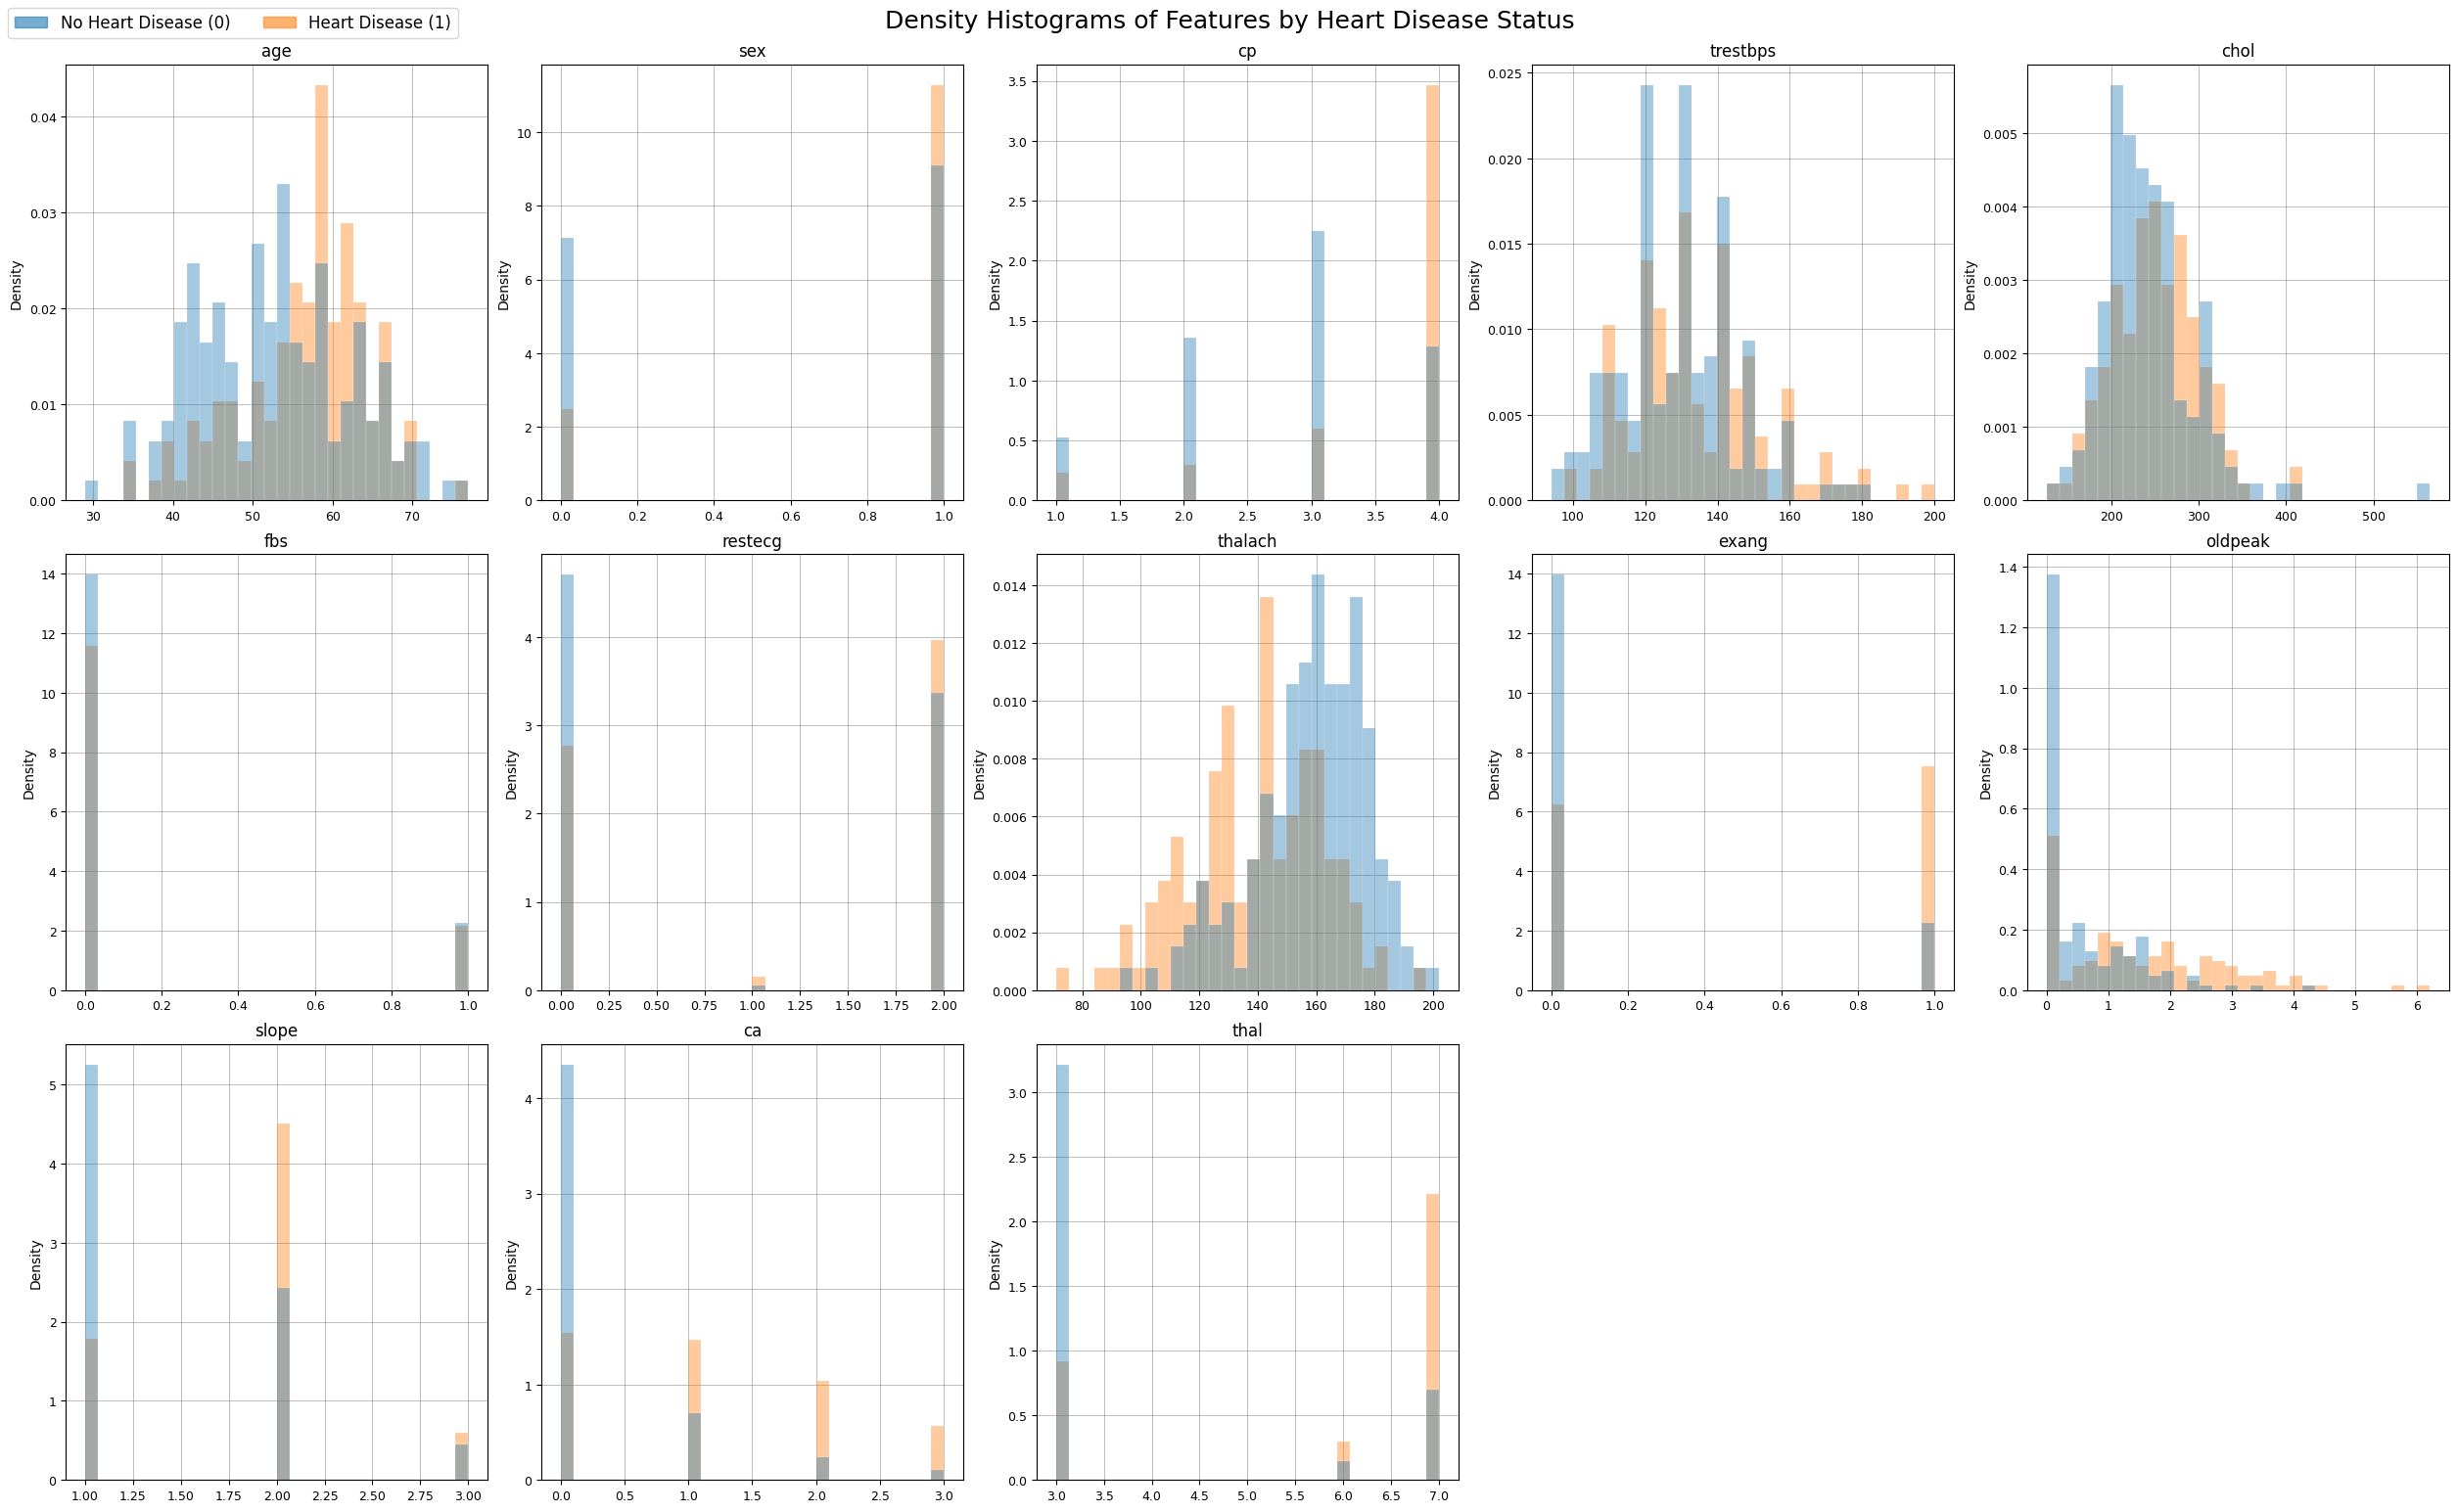

In [8]:
# Combine features with target for plotting
df_plot = X.copy()
df_plot["target"] = y

feature_names = X.columns
num_features = len(feature_names)

# Adjust subplot layout for 13 features (3 rows x 5 columns = 15 subplots)
fig, axes = plt.subplots(3, 5, figsize=(25, 15), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.histplot(
		data=df_plot,
		x=feature,
		hue="target",
		hue_order=[0, 1],  # Binary classification: 0 = no disease, 1 = disease
		stat="density",
		bins=30,
		alpha=0.4,
		edgecolor="white",
		linewidth=0.1,
		ax=axis,
		legend=False,
		palette=["#1f77b4", "#ff7f0e"],  # Use darker, more visible colors
	)
	axis.set_title(feature, fontsize=12)
	axis.set_xlabel("")
	axis.set_ylabel("Density", fontsize=10)
	axis.tick_params(axis="both", labelsize=9)
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Hide unused subplots (we have 13 features but 15 subplots)
for i in range(num_features, len(axes)):
	axes[i].set_visible(False)

# Single, consistent legend positioned outside the plots
handles = [
	plt.Rectangle((0, 0), 1, 1, color="#1f77b4", alpha=0.6),  # Updated colors to match
	plt.Rectangle((0, 0), 1, 1, color="#ff7f0e", alpha=0.6),  # Updated colors to match
]
fig.legend(
	handles,
	["No Heart Disease (0)", "Heart Disease (1)"],
	loc="upper left",
	ncol=2,
	frameon=True,
	fontsize=12,
)

# Overall figure adjustments for readability
fig.suptitle(
	"Density Histograms of Features by Heart Disease Status", fontsize=18, y=1.02
)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

### Phase 2 – Individual Models

Build and train three conceptually distinct models:

1. **Logistic Regression (`lr`)**

   * Baseline linear classifier.
   * Tune regularisation strength (`C`) and penalty type (`l2` preferred).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline with scaling and logistic regression
pipeline = Pipeline([
	("scaler", StandardScaler()),
	("lr", LogisticRegression(random_state=42, max_iter=1000)),
])

# Define the parameter grid with solver-penalty combinations
param_grid = [
	# lbfgs with l2 and None
	{
		"lr__solver": ["lbfgs"],
		"lr__penalty": ["l2", None],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
	# liblinear with l1 and l2
	{
		"lr__solver": ["liblinear"],
		"lr__penalty": ["l1", "l2"],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
	# saga with l1, l2, elasticnet, and None
	{
		"lr__solver": ["saga"],
		"lr__penalty": ["l1", "l2", None],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
]

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

# Fit on the training data
grid_search.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
lr = grid_search.best_estimator_

# Print the best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'lr__C': 1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
Best cross-validation accuracy: 0.8345


2. **K-Nearest Neighbours (`knn`)**

   * Non-parametric, instance-based model.
   * Choose a meaningful value of `n_neighbors` (e.g. 25–35) and justify your reasoning (trade-off between bias and variance).

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline with scaling and KNN
# Scaling is crucial for KNN as it's distance-based
pipeline = Pipeline([
	("scaler", StandardScaler()),
	("knn", KNeighborsClassifier()),
])

# Define the parameter grid for n_neighbors
# Testing values from 25-35 as suggested, plus some surrounding values
param_grid = {
	"knn__n_neighbors": [11, 15, 21, 25, 27, 31, 33, 35],
	"knn__weights": ["uniform", "distance"],
	"knn__metric": ["minkowski"],
	"knn__p": [1, 2],
	"knn__algorithm": ["auto"],
	"knn__leaf_size": [20, 30, 40],
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

# Fit on the training data (using imputed data)
grid_search.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
knn = grid_search.best_estimator_

# Print the best parameters and score
print(f"Best n_neighbors parameter: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best n_neighbors parameter: 11
Best cross-validation accuracy: 0.8429


3. **Decision Tree (`dt`)**

   * High-variance, rule-based learner.
   * Set a moderate `max_depth` and a small but non-zero `min_samples_leaf` to avoid overfitting.

Document the intuition for including each model — the ensemble only works if the base learners make *different kinds of errors*.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid_tree = {
	"criterion": ["gini", "entropy"],
	"max_depth": [None, 3, 5, 8, 12, 16],
	"min_samples_split": [2, 5, 10, 20],
	"min_samples_leaf": [1, 2, 5, 10, 20],
	"max_features": [None, "sqrt", "log2"],
	"class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(
	estimator=DecisionTreeClassifier(random_state=42),
	param_grid=param_grid_tree,
	cv=5,
	scoring="accuracy",
	n_jobs=-1,
	verbose=0,
	refit=True,
	return_train_score=True,
	error_score="raise",
)

# Fit the grid search on the training data (using imputed data)
grid_tree.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
dt = grid_tree.best_estimator_

# Print the best parameters and score
print(f"Best parameters: {grid_tree.best_params_}")
print(f"Best cross-validation accuracy: {grid_tree.best_score_:.4f}")

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validation accuracy: 0.7723


### Phase 3 – Model Evaluation

1. Train each classifier on the training data.
2. Evaluate on the test set using **accuracy**, **precision**, **recall**, and **F1-score**.
3. Compare the confusion matrices of all models to analyse error distribution.
4. Briefly discuss which models complement each other (e.g. tree capturing non-linearities missed by logistic regression).

In [24]:
from sklearn.metrics import classification_report

lr.fit(X_train_imputed, y_train.values.ravel())
y_pred = lr.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [25]:
from sklearn.metrics import classification_report

knn.fit(X_train_imputed, y_train.values.ravel())
y_pred = knn.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



In [26]:
from sklearn.metrics import classification_report

dt.fit(X_train_imputed, y_train.values.ravel())
y_pred = dt.predict(X_test_imputed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.64      0.71        33
           1       0.66      0.82      0.73        28

    accuracy                           0.72        61
   macro avg       0.73      0.73      0.72        61
weighted avg       0.74      0.72      0.72        61



### Phase 4 – Ensemble Construction

1. Combine the trained classifiers using `VotingClassifier` from `sklearn.ensemble`.
2. Implement both strategies:

   * **Hard Voting:** majority class vote.
   * **Soft Voting:** average predicted probabilities (requires classifiers that support `predict_proba`).
3. Evaluate ensemble performance using the same metrics as above.
4. Compare to the individual base models quantitatively and qualitatively.

### Phase 5 – Analytical Discussion

* If the ensemble outperforms all individual models, explain which component models contributed to that gain.
* If not, diagnose why — e.g. correlated errors, unbalanced votes, poor calibration.
* Reflect on bias–variance interplay across the three base models.
* Optionally, compute ROC-AUC and visualise the ROC curves for individual and ensemble models.

### Evaluation Criteria

A complete and rigorous answer demonstrates:

* Correct data pipeline and model training.
* Justified choice of hyperparameters and preprocessing methods.
* Balanced use of metrics (accuracy alone is insufficient).
* Analytical insight into model complementarity and ensemble behaviour.


#### Stretch Extensions

* Replace simple voting with **stacking**, training a meta-learner (e.g. Logistic Regression) on the outputs of the base classifiers.
* Evaluate robustness using **k-fold cross-validation**.
* Implement a simple **weighted voting scheme** assigning higher weight to better-performing models.